# 051 — Regional Delta Analysis (heteroscedastic / NLL)

Mirrors `050_delta_analysis.ipynb`, using `attention_unet_nll` (trained in `021_training_nll.ipynb`) instead of a deterministic checkpoint. The regional analysis in `scripts/delta_analysis.py` (structural delta, per-zone Wasserstein distance) is unchanged and runs on the predicted `mu` exactly as before. What's new is the model's own learned uncertainty `sigma`, added in a closing section as the **learned z-score** `(real_IR - mu) / sigma` — a color/context-conditioned alternative to the fixed Gaussian-window normalisation already used elsewhere in this notebook. See `code-review.md` §7.6.

**No trained checkpoint may exist yet** (`021_training_nll.ipynb` run still pending). This notebook falls back to a **synthetic** RGB/IR/sigma triple that exercises the same code path — a uniform gray-level offset region with a *high* synthetic sigma (a stand-in for a color the model has learned to expect variation in) and a structurally-altered region with a *low* synthetic sigma (a stand-in for a genuine, unexpected hidden mark). The z-score should stay small in the first region despite a large raw delta, and large in the second despite a smaller raw delta. Once a checkpoint exists at `models/attention_unet_nll/best_model.keras`, set `USE_SYNTHETIC_DATA = False` in section 2 to run on a real predicted/real IR pair instead — no other cell needs to change.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.trainer_nll import load_model_nll
from scripts.visualization import plot_delta, plot_delta_analysis, plot_predictions
from scripts.visualization_nll import plot_delta_comparison, plot_zscore

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load model (optional)

Attempts to load the best checkpoint for `ARCH`. If none exists yet (training in `021_training_nll.ipynb` hasn't produced `models/attention_unet_nll/best_model.keras`), `model` is set to `None` and section 2 falls back to synthetic data automatically.

In [3]:
ARCH = "attention_unet_nll"

try:
    model = load_model_nll(ARCH, model_dir=settings.MODELS_DIR)
    print(f"Loaded: {model.name} | Parameters: {model.count_params():,}")
except (FileNotFoundError, OSError) as exc:
    model = None
    print(f"No trained checkpoint found for '{ARCH}' ({exc}).")
    print("Falling back to synthetic data in section 2 — rerun once training completes.")

2026-08-11 15:37:42.532650: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-11 15:37:42.532678: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-11 15:37:42.532685: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-11 15:37:42.532699: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-11 15:37:42.532711: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded: attention_unet_nll | Parameters: 31,398,114


## 2. Real or synthetic (RGB, real IR, mu, sigma)

If `model` was loaded and a paired image exists in `data/test/rgb/` / `data/test/ir/`, runs real inference. Otherwise generates a synthetic `(real_ir, mu, sigma)` triple — see the note in the title cell for the two regions it exercises.

Set `IMAGE_STEM` below to pick a specific image from `data/test/rgb/` by filename stem. Leave it `None` to use the first available pair.

In [4]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR  = project_root / "data" / "test" / "ir"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) if TEST_RGB_DIR.exists() else []
test_pairs = [(p, TEST_IR_DIR / p.name) for p in rgb_paths if (TEST_IR_DIR / p.name).exists()]

USE_SYNTHETIC_DATA = model is None or not test_pairs
print(f"USE_SYNTHETIC_DATA = {USE_SYNTHETIC_DATA}")
print(f"Available pairs: {[p.stem for p, _ in test_pairs]}")

USE_SYNTHETIC_DATA = False
Available pairs: ['00', '02', '05', 'modern']


In [5]:
IMAGE_STEM = 'modern'  # e.g. "00" — pick a specific image from data/test/rgb/; None = first available


def make_synthetic_triple(size: int = 256, seed: int = 0):
    """Build a synthetic (real_ir, mu, sigma) triple for a dry run.

    Two regions with deliberately opposite raw-delta / sigma combinations,
    to exercise the learned z-score in `analyze_delta`'s spirit:

    - gray-level shift region: large raw delta, *high* synthetic sigma
      (a color the model has learned to expect variation in) -> small z.
    - structurally-altered region: smaller raw delta, *low* synthetic
      sigma (an unexpected pattern) -> large z.
    """
    rng = np.random.default_rng(seed)
    x, y = np.meshgrid(np.linspace(0, 6 * np.pi, size), np.linspace(0, 6 * np.pi, size))
    texture = 0.5 + 0.25 * np.sin(x) * np.cos(y)
    real = np.clip(texture + rng.normal(0, 0.02, size=(size, size)), 0.0, 1.0)

    mu = real.copy()
    sigma = np.full((size, size), 0.05, dtype=np.float32)

    s = size // 4
    # Gray-level shift region (substrate/acquisition-like): large delta,
    # but the model has "learned" this color region is historically variable.
    mu[s : 2 * s, s : 2 * s] = np.clip(mu[s : 2 * s, s : 2 * s] - 0.2, 0.0, 1.0)
    sigma[s : 2 * s, s : 2 * s] = 0.25

    # Structurally-altered region (genuine-mark-like): the model has no
    # reason to expect variation here, so sigma stays at the low baseline.
    mu[3 * s : 4 * s, 3 * s : 4 * s] = rng.random((s, s))

    return real.astype(np.float32), mu.astype(np.float32), sigma


def select_pair(pairs, stem):
    """Return the (rgb, ir) path pair matching stem, or the first pair if None."""
    if stem is None:
        return pairs[0]
    matches = [pair for pair in pairs if pair[0].stem == stem]
    if not matches:
        available = [p.stem for p, _ in pairs]
        raise ValueError(f"IMAGE_STEM='{stem}' not found. Available: {available}")
    return matches[0]


if USE_SYNTHETIC_DATA:
    ir_real, mu, sigma = make_synthetic_triple()
    rgb = np.stack([ir_real] * 3, axis=-1)  # placeholder RGB for display only
    pair_label = "synthetic"
else:
    rgb_path, ir_path = select_pair(test_pairs, IMAGE_STEM)
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir_real = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0

    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    pred_full = model.predict(padded[tf.newaxis, ...], verbose=0)[0]
    h, w = ir_real.shape
    mu = pred_full[:h, :w, 0]
    log_var = pred_full[:h, :w, 1]
    sigma = np.exp(0.5 * log_var)
    pair_label = rgb_path.stem

print(f"Pair: {pair_label} | shape: {ir_real.shape}")

2026-08-11 15:38:25.734291: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Pair: modern | shape: (1052, 1885)


## 3. Baseline: RGB / real IR / predicted mu and raw delta

Same visualisation as `040_inference.ipynb` / `050_delta_analysis.ipynb`, for reference before the regional and z-score analysis.

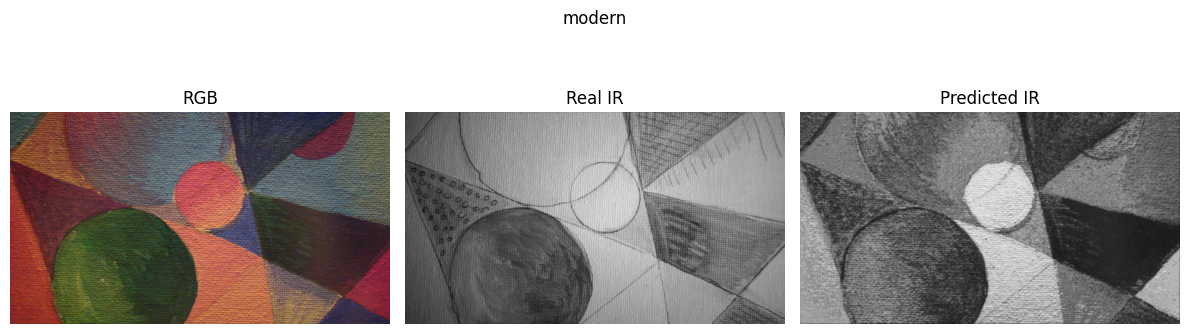

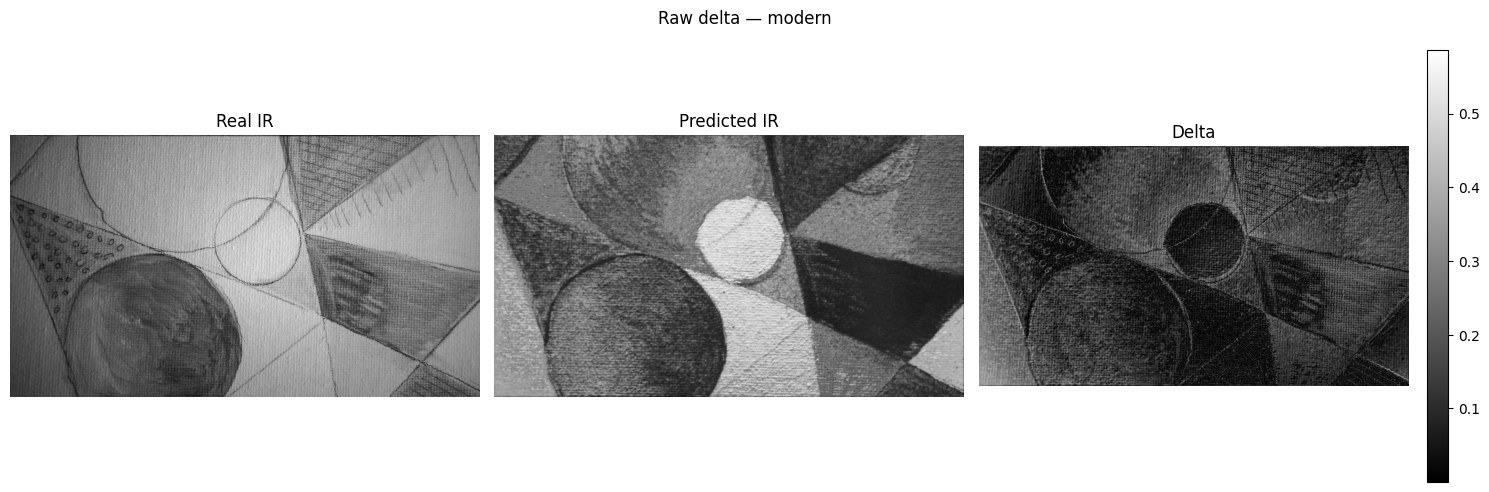

In [6]:
fig = plot_predictions(rgb, ir_real, mu, title=pair_label)
plt.show()

fig = plot_delta(ir_real, mu, title=f"Raw delta — {pair_label}")
plt.show()

## 4. Regional delta analysis (structural, on `mu`)

Unchanged from `050_delta_analysis.ipynb`: `analyze_delta` runs on `(ir_real, mu)` exactly as it would on any deterministic prediction — the structural/zone decomposition doesn't depend on how the prediction was produced.

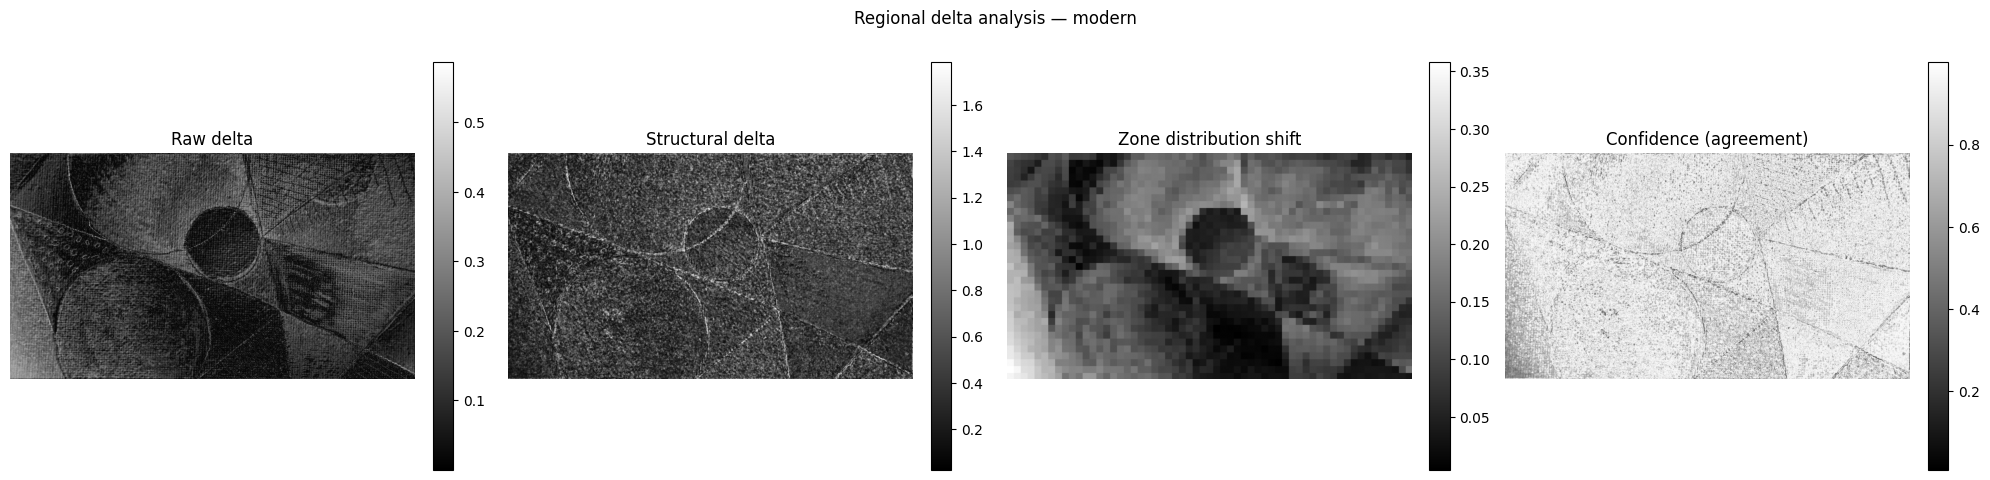

In [7]:
result = analyze_delta(ir_real, mu, window_size=11, zone_size=32)

fig = plot_delta_analysis(result, title=f"Regional delta analysis — {pair_label}")
plt.show()

## 5. Luminance / contrast / structure maps

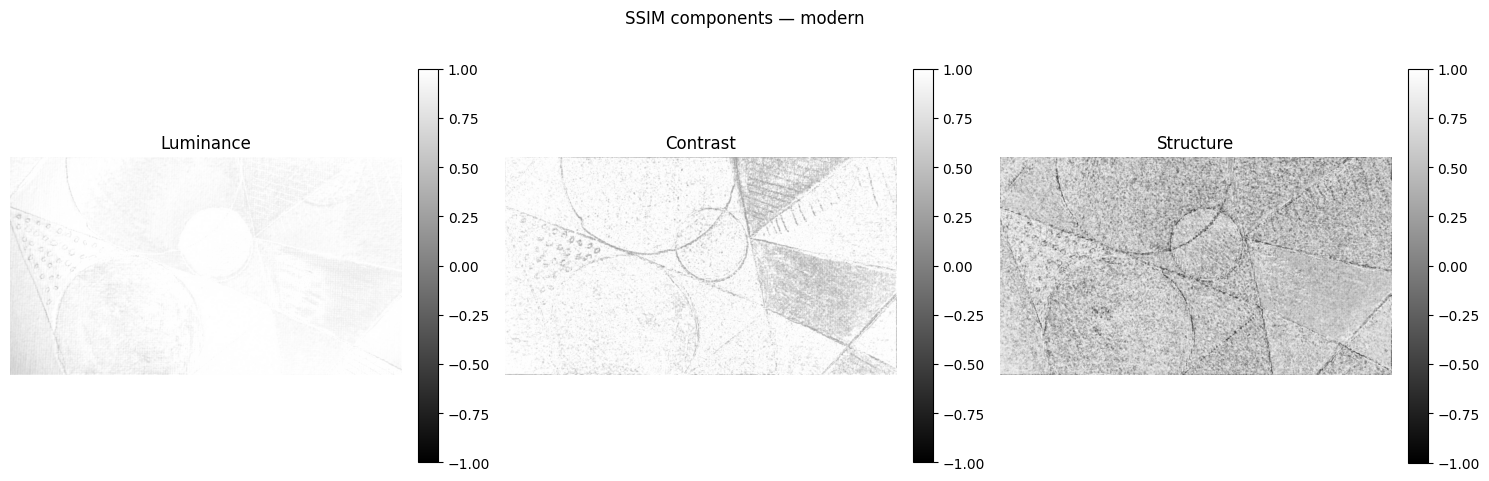

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"SSIM components — {pair_label}")

for ax, (name, data) in zip(
    axes,
    [
        ("Luminance", result.luminance_map),
        ("Contrast", result.contrast_map),
        ("Structure", result.structure_map),
    ],
):
    im = ax.imshow(data, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 6. Learned anomaly z-score

New section, specific to the heteroscedastic model: `z = (real_IR - mu) / sigma`. Unlike the fixed Gaussian-window normalisation behind `normalized_delta` above (section 4), `sigma` is conditioned on RGB context alone, learned end-to-end from how much the same color has historically varied in IR across the training set — see `code-review.md` §7.6.

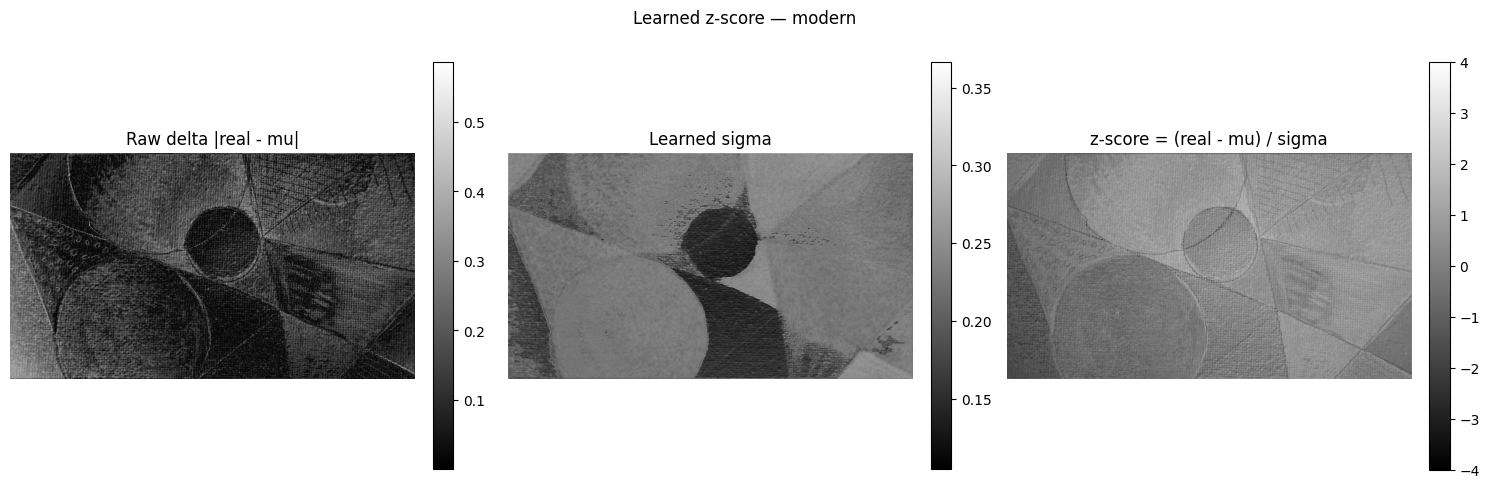

In [9]:
fig = plot_zscore(ir_real, mu, sigma, title=f"Learned z-score — {pair_label}")
plt.show()

## 7. Comparing every way this pipeline highlights hidden detail

One figure, every signal side by side: raw delta, structural delta (insensitive to gray-level shifts), the fixed-window normalized delta (`note.md` §2), the learned z-score (`note.md` "Update" section, `code-review.md` §7.6), and the raw/structural confidence map. See `note.md` for what each one actually normalizes against and where each has a blind spot the others cover — this panel is the practical counterpart of that discussion, meant to help spot underdrawings, pentimenti, and other hidden elements at a glance rather than reading one map at a time.

In [ ]:
fig = plot_delta_comparison(
    result,
    ir_real,
    mu,
    sigma,
    title=f"Delta comparison — {pair_label}",
)
plt.show()